# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daniyalhaider236/flyrank-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*



**Which of a content portfolio's pages are worth reviewing first for a refresh, and why?**

This supports a real content-ops decision: with limited review capacity, which pages should a team look
at this cycle, in what order, and with what justification — not "which pages are declining" in the
abstract, but a ranked, explainable queue a human can act on.

**Lane:** Refresh / Content Opportunity Scoring (Lane 2), locked in Week 1–3.

In [16]:
print("Lane 2 — Refresh / Content Opportunity Scoring")
print("Decision supported: review-order prioritization for a content team, not automated action.")

Lane 2 — Refresh / Content Opportunity Scoring
Decision supported: review-order prioritization for a content team, not automated action.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*



**Source:** the FlyRank ML Internship starter dataset — 30,000 anonymized content pages across 32
anonymized client accounts, three content types (comparison article, feedly article, keyword article).
Each row aggregates a 90-day trailing window plus two sequential 30-day comparison windows
(`*_last_30d` vs `*_prev_30d`) used to compute a trend label.

**Excluded from modeling, and why:**
- `trend_direction` / `trend_pct` and all six `*_last_30d` / `*_prev_30d` columns — confirmed
  label-derived (Methodology section explains the check).
- `impressions_90d`, `clicks_90d`, `pageviews_90d`, `sessions_90d` — these fully contain the exact 30-day
  window the label is built from; kept out on principle even though the measured effect of including them
  was modest.

**Public-safe:** no client names, domains, raw exports, or credentials appear anywhere in this repo or
this page — client and content identifiers are anonymized hashes provided by the dataset itself.

In [17]:
import pandas as pd
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(f"Rows: {len(df)}, Clients: {df['client_id'].nunique()}, Content types: {df['content_type'].unique().tolist()}")
print(f"Columns excluded from every model in this repo: trend_direction, trend_pct, "
      f"*_last_30d, *_prev_30d, and the four *_90d volume aggregates.")

Rows: 30000, Clients: 32, Content types: ['keyword article', 'feedly article', 'comparison article']
Columns excluded from every model in this repo: trend_direction, trend_pct, *_last_30d, *_prev_30d, and the four *_90d volume aggregates.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*



**Assumption:** a page's own structural and historical signals — how old it is, how long since it was
last updated, its position, its CTR, its length, and its content type — carry information about whether
it's currently in a declining traffic trend, independent of the specific 30-day windows used to define
that trend.

**Label:** `trend_direction == "down"`. This is calculated from a 30-day-vs-previous-30-day impression
change (confirmed by correlating a manually reconstructed version against the disclosed `trend_pct`
column: r = 0.9999999984). One disclosure: the FlyRank research paper documents a ±10% threshold for this
label; this dataset's actual observed cutoff is closer to ±20% — noted, not assumed away.

**Features:** `content_age_days`, `days_since_last_update`, `avg_position`, `ctr`, `word_count`,
`search_volume`, `competition` (each with a missingness flag), and one-hot `content_type`.

**Baseline (Week 4):** a transparent rule — `stale (≥90 days) × visible (≥300 impressions) ×
impressions_90d` — one reason code, one action label.

**Model:** Logistic Regression, compared against Random Forest, both evaluated by Precision@20/@50 (the
task is ranking, not classification).

**Validation design:** `GroupShuffleSplit` by `client_id` (75/25) — content decisions need to generalize
to clients the model hasn't seen, not just held-out rows from clients already in training. A single split
is a noisy estimate with only 32 total clients, so the same architecture was re-run across 5 different
client holdouts to report a range, not one number.

In [18]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

df["is_declining_label"] = (df["trend_direction"].str.lower() == "down").astype(int)
computed_trend = ((df["impressions_last_30d"] - df["impressions_prev_30d"])
                   / df["impressions_prev_30d"].replace(0, np.nan) * 100)
print("Label-leakage check — correlation of computed trend vs disclosed trend_pct:",
      round(computed_trend.corr(df["trend_pct"]), 10))
down_max = df.loc[df["trend_direction"] == "down", "trend_pct"].max()
print(f"Observed 'down' cutoff in this dataset: trend_pct <= {down_max} (paper discloses -10)")

Label-leakage check — correlation of computed trend vs disclosed trend_pct: 0.9999999984
Observed 'down' cutoff in this dataset: trend_pct <= -20.0 (paper discloses -10)


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*



| Method | Precision@20 | Precision@50 |
|---|---|---|
| Base rate (random order) | 0.517 | 0.517 |
| Week-4 baseline rule | 0.200 | 0.300 |
| Random Forest | 0.300 | 0.440 |
| **Logistic Regression** | **0.750** | **0.680** |

Across 5 different client holdouts, Logistic Regression's Precision@20 ranged 0.50–0.75 (mean 0.68) and
Precision@50 ranged 0.48–0.80 (mean 0.64) — directionally ahead of the baseline in every case, but the
exact margin depends on which clients are held out. The baseline rule underperforms random ordering here;
Week 4's own signal check already showed volume was not a clean, monotonic decline predictor, so this
isn't a new failure, it's the same finding confirmed a second way. Random Forest did not beat the simpler
model — added complexity wasn't rewarded on this data.

In [19]:
import json
with open("work/outputs/w07_metrics.json") as f:
    metrics = json.load(f)
perf = metrics["validated_performance_w06"]
print(pd.DataFrame([
    {"method": "Base rate", "P@20": perf["base_rate"], "P@50": perf["base_rate"]},
    {"method": "Week-4 baseline", **{"P@20": perf["week4_baseline_rule"]["precision_at_20"],
                                       "P@50": perf["week4_baseline_rule"]["precision_at_50"]}},
    {"method": "Random Forest", **{"P@20": perf["random_forest_single_split_seed42"]["precision_at_20"],
                                     "P@50": perf["random_forest_single_split_seed42"]["precision_at_50"]}},
    {"method": "Logistic Regression", **{"P@20": perf["logistic_regression_single_split_seed42"]["precision_at_20"],
                                           "P@50": perf["logistic_regression_single_split_seed42"]["precision_at_50"]}},
]).to_string(index=False))

             method  P@20  P@50
          Base rate 0.517 0.517
    Week-4 baseline 0.200 0.300
      Random Forest 0.300 0.440
Logistic Regression 0.750 0.680


## 5. Limitations

*What this work cannot claim.*



- **Not causal.** This ranks association with a declining-trend label; it does not measure or prove that
  refreshing a page *causes* recovery.
- **Single-split numbers are noisy.** With 32 total clients, any one holdout's Precision@K should be read
  against the 0.50–0.75 range, not trusted as a fixed number.
- **56% of the dataset (16,858 rows) shares a near-identical feature profile with at least 5 other pages
  that had different real outcomes.** The model separates cohorts reliably; it often cannot tell winners
  from losers within an identical-looking cohort.
- **Small slices are unstable.** Buckets under ~200 rows (seen in the Week-4 signal checks) should not be
  treated as reliable on their own.
- **This is a snapshot of an anonymized starter file, not the full warehouse**, and its label threshold
  (~±20%) does not match the FlyRank paper's disclosed ±10% — a reminder that documented methodology and
  the actual data in hand can quietly diverge.
- **Missing data is imputed and flagged**, not observed, for 8–26% of rows depending on the field.

In [20]:
print(f"Rows sharing a mixed-outcome profile: {metrics['human_review_flag']['rows_affected']} "
      f"({metrics['human_review_flag']['share_of_dataset']:.1%} of dataset)")

Rows sharing a mixed-outcome profile: 16858 (56.2% of dataset)


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*



Five archetypes, ranked by tier first (finish higher tiers before lower ones), then by
`decline_probability × impressions_90d` within each tier:

| Archetype | Share | Decline rate | Action |
|---|---|---|---|
| Priority Refresh | 23.9% | 66.4% | `review_for_refresh` |
| Quiet Decline | 9.5% | 58.4% | `monitor_low_priority` |
| Watch | 33.3% | 59.7% | `watch_next_cycle` |
| Protect | 18.0% | 45.0% | `protect_periodic_check` |
| Low Priority | 15.3% | 31.4% | `monitor_only` |

**Human review is required** before acting on Priority Refresh or Quiet Decline — checking real content
quality, technical/indexing issues, and fading keyword demand. **Nothing here should be automated**: no
auto-publishing, no treating any single page's score as a guarantee, no use in evaluating individual
writers or teams. Full detail in `work/notebooks/w07_action_playbook.ipynb`.

In [21]:
print(metrics["archetype_counts"])
print(metrics["archetype_decline_rates"])

{'Priority Refresh': 7162, 'Quiet Decline': 2838, 'Watch': 10000, 'Protect': 5409, 'Low Priority': 4591}
{'Priority Refresh': 0.6642, 'Quiet Decline': 0.5839, 'Watch': 0.5971, 'Protect': 0.45, 'Low Priority': 0.3143}


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

work/figures/archetype_distribution.png exists: True


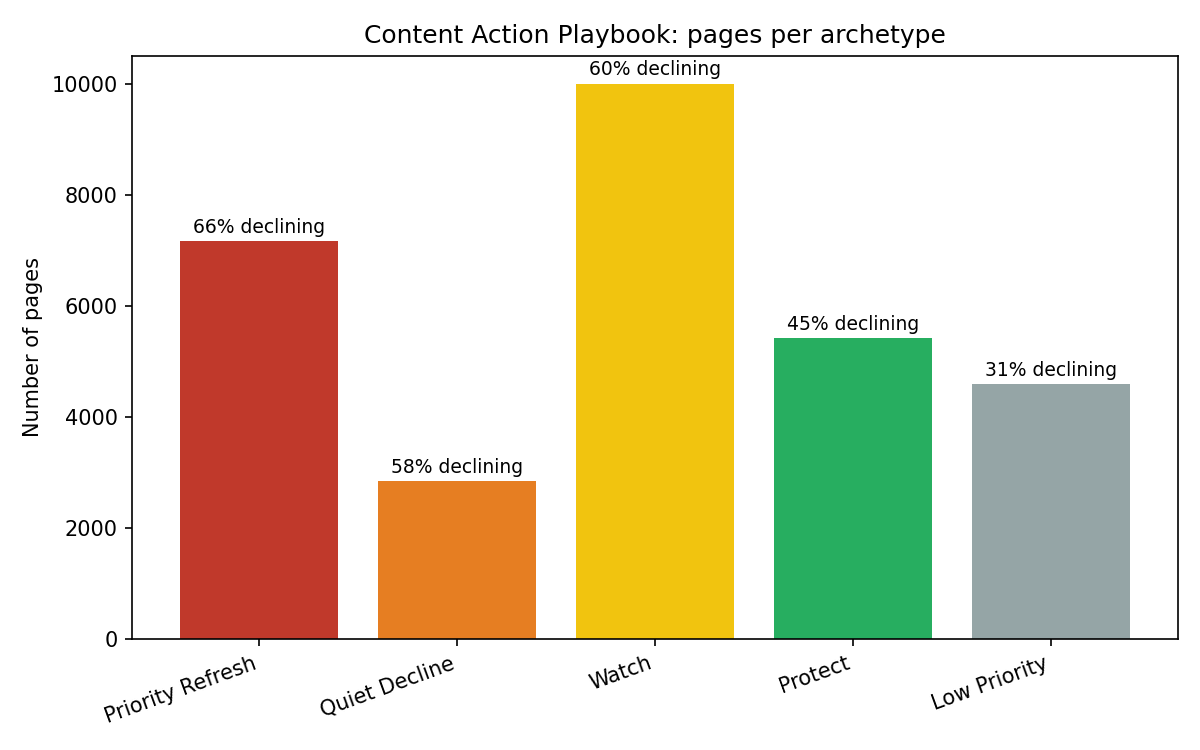

work/figures/model_vs_baseline.png exists: True


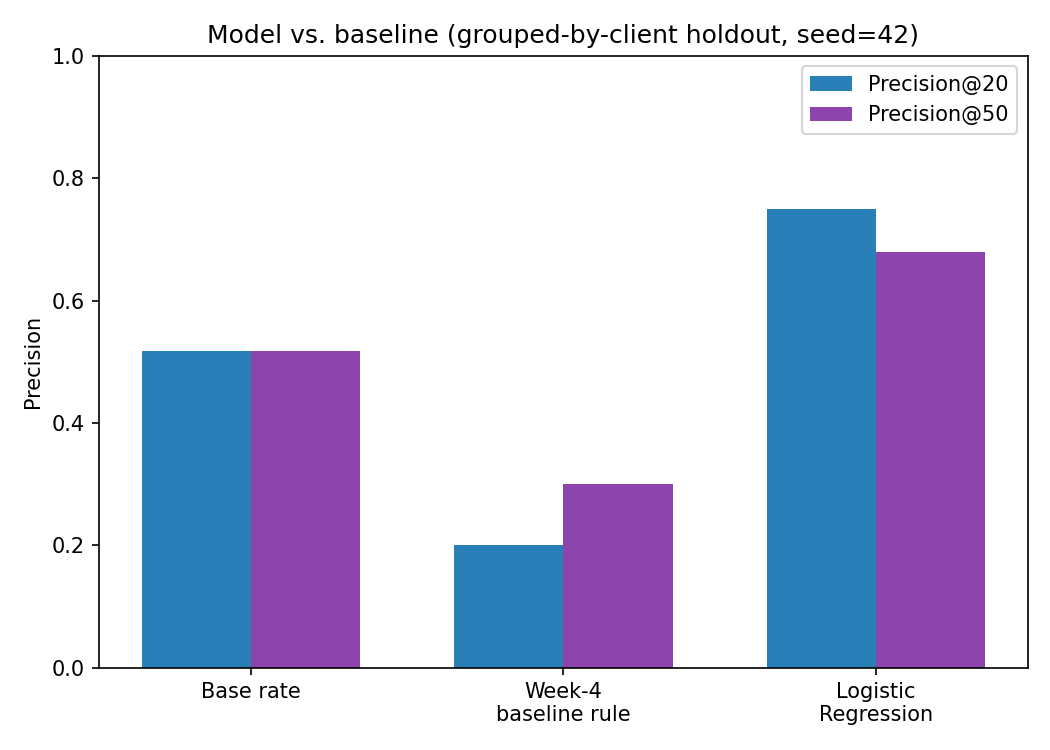

In [22]:
import os
from IPython.display import Image, display
for fig in ["work/figures/archetype_distribution.png", "work/figures/model_vs_baseline.png"]:
    print(fig, "exists:", os.path.exists(fig))
    display(Image(fig))

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
